<a href="https://colab.research.google.com/github/ftmrocca/CUBO-OLAP/blob/main/OLAP_Cubo_PySpark_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cubo OLAP con PySpark en Google Colab

Este notebook está preparado para ejecutarse en Colab y usa el modelo en estrella exportado desde SQL Server. Se clona el repositorio, se instala PySpark y se crean visualizaciones OLAP.

## 1. Preparación del entorno

Instala las dependencias necesarias y clona el repositorio para acceder a los CSV.

In [9]:
!pip install --quiet pyspark pandas matplotlib seaborn
!git clone --depth 1 https://github.com/ftmrocca/CUBO-OLAP.git /content/CUBO-OLAP || true
import os
base_path = '/content/CUBO-OLAP'
assert os.path.exists(base_path), 'El repositorio no se clonó correctamente.'
print('base_path:', base_path)

Cloning into '/content/CUBO-OLAP'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 4.94 MiB | 5.01 MiB/s, done.
base_path: /content/CUBO-OLAP


## 2. Crear sesión Spark y cargar datos

Creamos la sesión de Spark, cargamos cada dimensión y la tabla de hechos desde los CSV.

In [10]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, when, round, sum as spark_sum

spark = (SparkSession.builder
    .appName('CuboOLAPColab')
    .master('local[*]')
    .getOrCreate())

dim_candidate = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(f'{base_path}/dim_candidate.csv'))

dim_education = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(f'{base_path}/dim_education.csv'))

dim_skills = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(f'{base_path}/dim_skills.csv'))

dim_time = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(f'{base_path}/dim_time.csv'))

fact_employability = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(f'{base_path}/fact_employability.csv'))

print('Datos cargados con éxito')
print('dim_candidate rows:', dim_candidate.count())
print('fact_employability rows:', fact_employability.count())

Datos cargados con éxito
dim_candidate rows: 432
fact_employability rows: 293445


## 3. Construcción del cubo OLAP

Unimos las dimensiones con la tabla de hechos para crear el cubo analítico.

In [11]:
cube_df = (fact_employability
    .join(dim_candidate, 'candidate_id', 'left')
    .join(dim_education, 'education_id', 'left')
    .join(dim_skills, 'skills_id', 'left')
    .join(dim_time, 'time_id', 'left'))

cube_df.createOrReplaceTempView('cube')
cube_df.printSchema()

root
 |-- time_id: integer (nullable = true)
 |-- skills_id: integer (nullable = true)
 |-- education_id: integer (nullable = true)
 |-- candidate_id: integer (nullable = true)
 |-- fact_id: integer (nullable = true)
 |-- employment_status: string (nullable = true)
 |-- salary: integer (nullable = true)
 |-- job_sector: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- country_of_origin: string (nullable = true)
 |-- education_level: string (nullable = true)
 |-- field_of_study: string (nullable = true)
 |-- university_ranking: string (nullable = true)
 |-- region_of_study: string (nullable = true)
 |-- gpa: double (nullable = true)
 |-- language_proficiency: string (nullable = true)
 |-- internship_experience: string (nullable = true)
 |-- graduation_date: date (nullable = true)
 |-- years_since_graduation: integer (nullable = true)



## 4. Visualizaciones OLAP

Estas celdas generan gráficos que muestran distintos cortes y agregaciones del cubo.

### 4.1 Distribución de candidatos por género y país

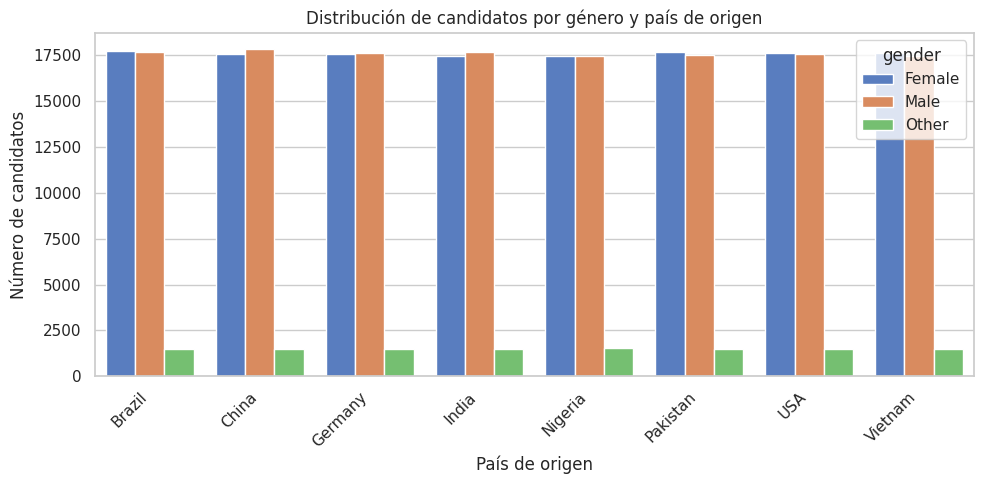

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', palette='muted')

gender_country = cube_df.groupBy('gender', 'country_of_origin').agg(count('*').alias('count')).orderBy('gender', 'country_of_origin')
pdf = gender_country.toPandas()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=pdf, x='country_of_origin', y='count', hue='gender', ax=ax)
ax.set_title('Distribución de candidatos por género y país de origen')
ax.set_xlabel('País de origen')
ax.set_ylabel('Número de candidatos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.2 Tasa de empleo por nivel educativo

/tmp/ipykernel_4155/129913168.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf, x='education_level', y='employment_rate', palette='Blues_d', ax=ax)


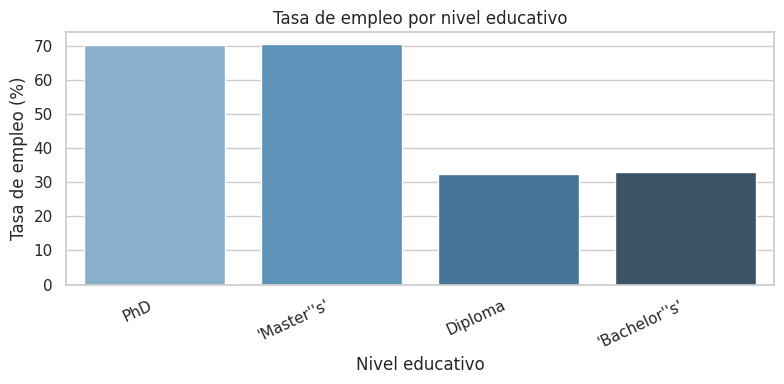

In [13]:
education_employment = cube_df.groupBy('education_level').agg(
    count('*').alias('total'),
    spark_sum(when(col('employment_status') == 'Employed', 1).otherwise(0)).alias('employed')
)
education_employment = education_employment.withColumn('employment_rate', round(col('employed') / col('total') * 100, 2))
pdf = education_employment.toPandas()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=pdf, x='education_level', y='employment_rate', palette='Blues_d', ax=ax)
ax.set_title('Tasa de empleo por nivel educativo')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Tasa de empleo (%)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### 4.3 Salario promedio por sector y país

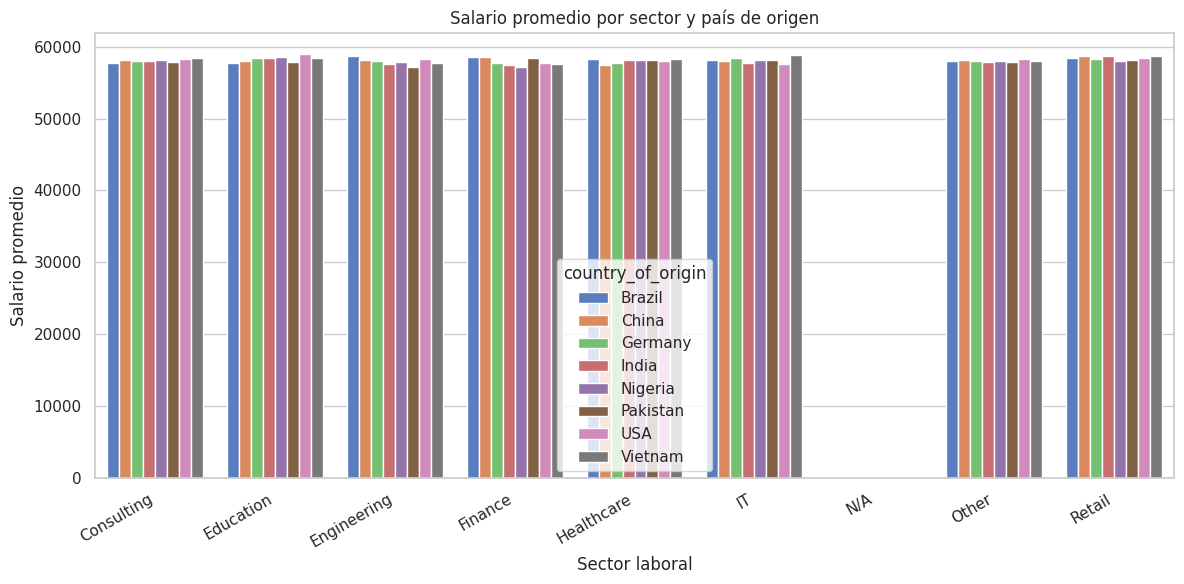

In [14]:
salary_sector = cube_df.groupBy('job_sector', 'country_of_origin').agg(round(avg('salary'), 2).alias('avg_salary')).orderBy('job_sector', 'country_of_origin')
pdf = salary_sector.toPandas()
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=pdf, x='job_sector', y='avg_salary', hue='country_of_origin', ax=ax)
ax.set_title('Salario promedio por sector y país de origen')
ax.set_xlabel('Sector laboral')
ax.set_ylabel('Salario promedio')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 4.4 Experiencia de prácticas vs años desde graduación

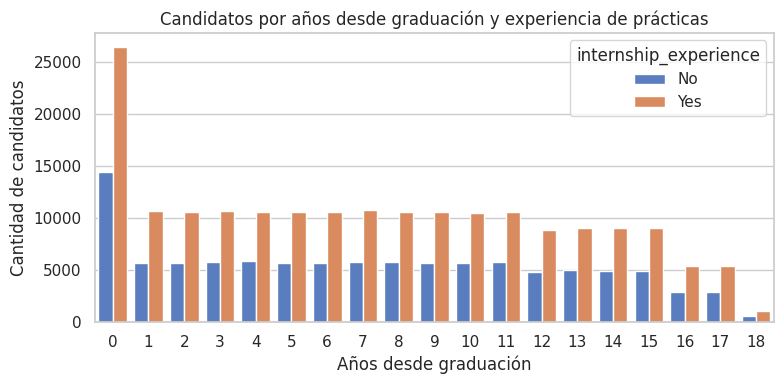

In [15]:
experience_grad = cube_df.groupBy('years_since_graduation', 'internship_experience').agg(count('*').alias('count')).orderBy('years_since_graduation')
pdf = experience_grad.toPandas()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=pdf, x='years_since_graduation', y='count', hue='internship_experience', ax=ax)
ax.set_title('Candidatos por años desde graduación y experiencia de prácticas')
ax.set_xlabel('Años desde graduación')
ax.set_ylabel('Cantidad de candidatos')
plt.tight_layout()
plt.show()

### 4.5 Salario promedio por ranking universitario

/tmp/ipykernel_4155/1163330090.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf, x='university_ranking', y='avg_salary', palette='viridis', ax=ax)


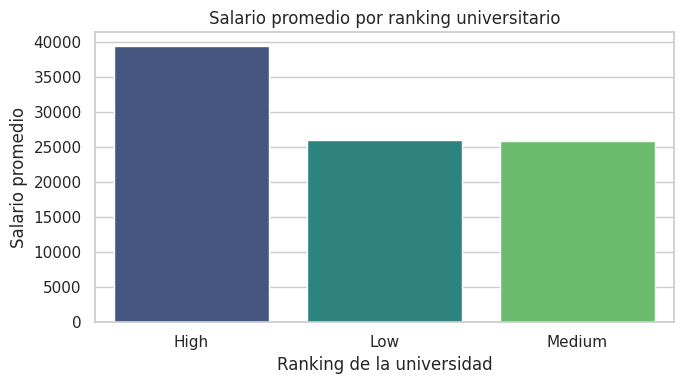

In [16]:
salary_ranking = cube_df.groupBy('university_ranking').agg(round(avg('salary'), 2).alias('avg_salary')).orderBy('university_ranking')
pdf = salary_ranking.toPandas()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pdf, x='university_ranking', y='avg_salary', palette='viridis', ax=ax)
ax.set_title('Salario promedio por ranking universitario')
ax.set_xlabel('Ranking de la universidad')
ax.set_ylabel('Salario promedio')
plt.tight_layout()
plt.show()

## 6. Análisis Exploratorio Avanzado y Correlaciones
En esta sección profundizamos en la estructura del cubo mediante visualizaciones estadísticas avanzadas.

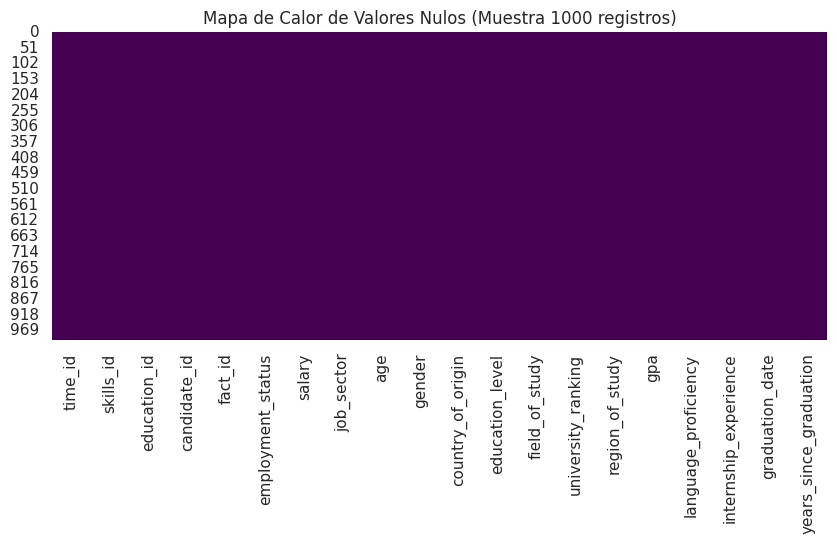

In [17]:
import numpy as np
# 6.1 Heatmap de Nulos
pdf_sample = cube_df.limit(1000).toPandas()
plt.figure(figsize=(10, 4))
sns.heatmap(pdf_sample.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Nulos (Muestra 1000 registros)')
plt.show()

**Análisis de Nulos:** Esta visualización permite identificar rápidamente si existen patrones de pérdida de datos. Las líneas amarillas indicarían datos faltantes; en este caso, nos ayuda a validar la integridad del JOIN realizado en el cubo.

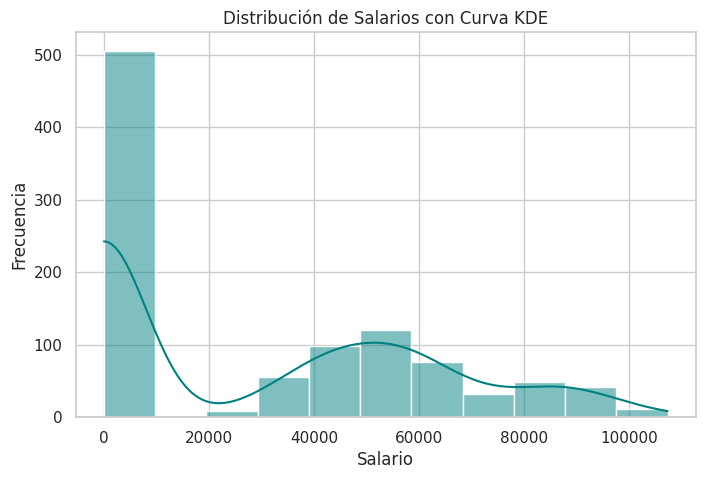

In [18]:
# 6.2 Histograma + Curva KDE del Salario
plt.figure(figsize=(8, 5))
sns.histplot(pdf_sample['salary'], kde=True, color='teal')
plt.title('Distribución de Salarios con Curva KDE')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')
plt.show()

**Análisis de Distribución:** El histograma muestra la frecuencia de los salarios, mientras que la curva KDE (Kernel Density Estimate) suaviza la distribución para identificar modas o sesgos. Esto revela si la mayoría de los candidatos se concentran en rangos salariales bajos o altos.

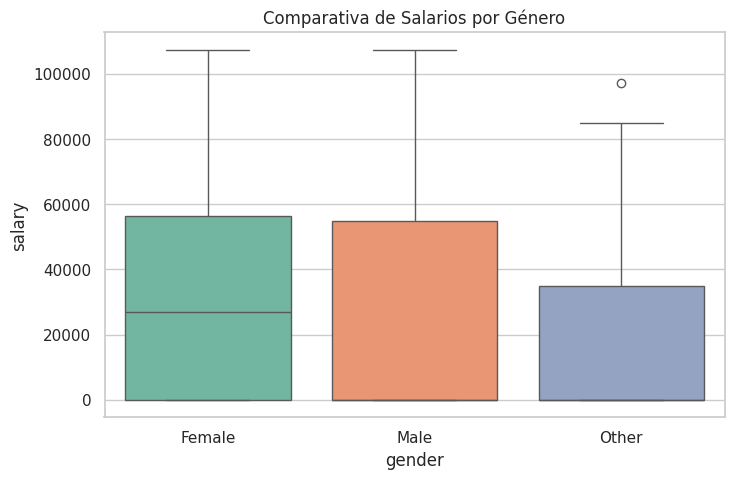

In [19]:
# 6.3 Boxplot Comparativo: Salario por Género
plt.figure(figsize=(8, 5))
sns.boxplot(data=pdf_sample, x='gender', y='salary', palette='Set2', hue='gender', legend=False)
plt.title('Comparativa de Salarios por Género')
plt.show()

**Análisis de Boxplot:** Representa la mediana, los cuartiles y los valores atípicos (outliers). Sirve para detectar disparidades salariales y variabilidad de ingresos entre diferentes grupos de género.

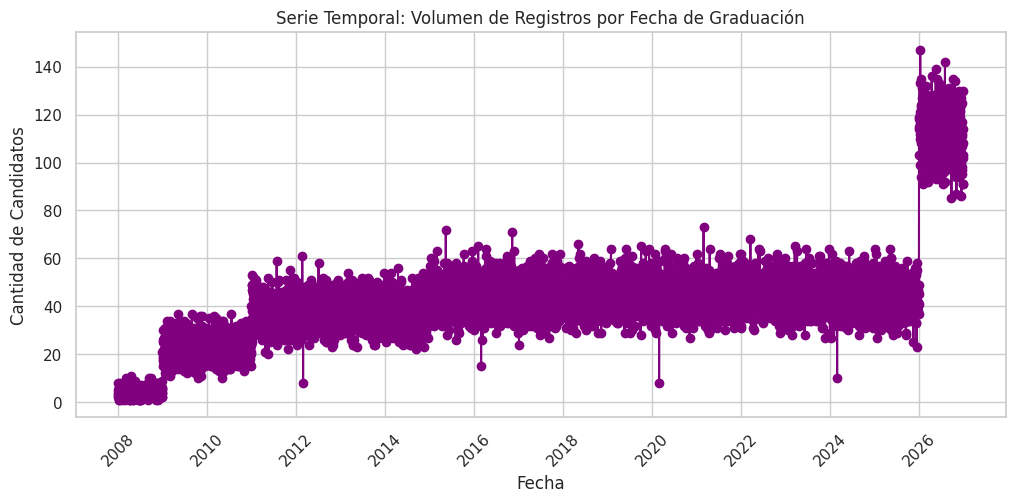

In [20]:
# 6.4 Serie Temporal: Volumen de graduaciones por fecha
time_series = cube_df.groupBy('graduation_date').agg(count('*').alias('volumen')).orderBy('graduation_date').toPandas()
plt.figure(figsize=(12, 5))
plt.plot(time_series['graduation_date'], time_series['volumen'], marker='o', linestyle='-', color='purple')
plt.title('Serie Temporal: Volumen de Registros por Fecha de Graduación')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Candidatos')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Análisis Temporal:** Esta gráfica de líneas muestra cómo ha evolucionado el flujo de graduados en el tiempo. Permite detectar estacionalidad (picos en ciertos meses) o tendencias de crecimiento en la base de datos.

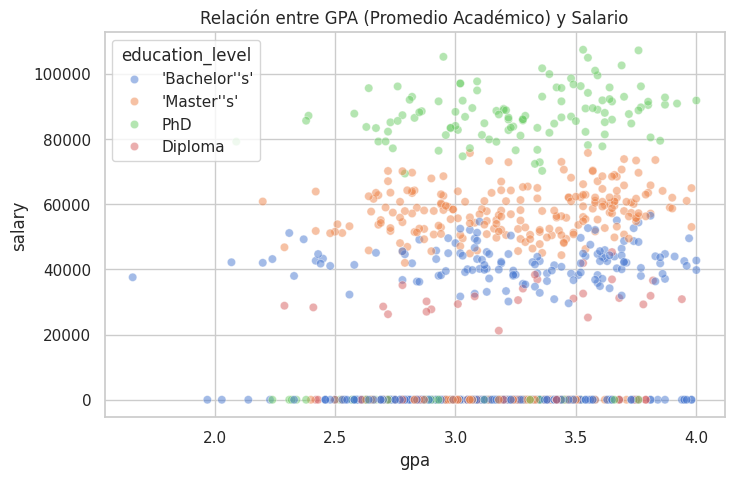

In [21]:
# 6.5 Scatter Plot: GPA vs Salario
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pdf_sample, x='gpa', y='salary', alpha=0.5, hue='education_level')
plt.title('Relación entre GPA (Promedio Académico) y Salario')
plt.show()

**Análisis de Correlación (Scatter):** El gráfico de dispersión ayuda a visualizar si existe una relación directa entre el rendimiento académico (GPA) y el salario inicial. Si los puntos forman una línea ascendente, habría una correlación positiva.

## 7. Preguntas y Respuestas basadas en el Cubo OLAP

In [22]:
print('1. De las personas que no tienen salario, ¿cual es la causa mayor de un salario = 0, que están desempleados o que siguen estudiando?')

salary_zero_analysis = cube_df.filter(col('salary') == 0)
salary_zero_employment = salary_zero_analysis.groupBy('employment_status').count().toPandas()
salary_zero_education = salary_zero_analysis.groupBy('education_level').count().toPandas()

print('\nAnálisis de personas con salario = 0:')
print('Por estado de empleo:')
print(salary_zero_employment)
print('\nPor nivel educativo:')
print(salary_zero_education)

# Determinar la causa mayor
most_common_employment_status = salary_zero_employment.loc[salary_zero_employment['count'].idxmax()]
print(f"\nRespuesta 1: La mayor causa de un salario de 0 para las personas en este dataset es que su estado de empleo es '{most_common_employment_status['employment_status']}'.")

1. De las personas que no tienen salario, ¿cual es la causa mayor de un salario = 0, que están desempleados o que siguen estudiando?

Análisis de personas con salario = 0:
Por estado de empleo:
      employment_status  count
0  Continuing Education  73670
1            Unemployed  68298

Por nivel educativo:
  education_level  count
0             PhD  13049
1     'Master''s'  30320
2         Diploma  19755
3   'Bachelor''s'  78844

Respuesta 1: La mayor causa de un salario de 0 para las personas en este dataset es que su estado de empleo es 'Continuing Education'.


In [23]:
print('\n2. ¿Cuál es la mayor causa relacionada con el desempleo, el level of studies, field of study...?')

unemployed_analysis = cube_df.filter(col('employment_status') == 'Unemployed')

unemployed_education_level = unemployed_analysis.groupBy('education_level').count().orderBy(col('count').desc()).toPandas()
unemployed_field_of_study = unemployed_analysis.groupBy('field_of_study').count().orderBy(col('count').desc()).toPandas()

print('\nAnálisis de desempleados:')
print('Por nivel educativo:')
print(unemployed_education_level.head())
print('\nPor campo de estudio:')
print(unemployed_field_of_study.head())

most_common_unemployed_education = unemployed_education_level.iloc[0]
most_common_unemployed_field = unemployed_field_of_study.iloc[0]

print(f"\nRespuesta 2: La mayor causa relacionada con el desempleo en términos de nivel educativo es '{most_common_unemployed_education['education_level']}' y en campo de estudio es '{most_common_unemployed_field['field_of_study']}'.")


2. ¿Cuál es la mayor causa relacionada con el desempleo, el level of studies, field of study...?

Análisis de desempleados:
Por nivel educativo:
  education_level  count
0   'Bachelor''s'  42712
1         Diploma  10701
2     'Master''s'  10397
3             PhD   4488

Por campo de estudio:
    field_of_study  count
0  Social Sciences  11446
1      Engineering  11437
2         Business  11398
3             Arts  11375
4           Health  11333

Respuesta 2: La mayor causa relacionada con el desempleo en términos de nivel educativo es ''Bachelor''s'' y en campo de estudio es 'Social Sciences'.


In [24]:
print('\n3. ¿Existe una relación verdadera entre el GPA y el salario? O el rendimiento académico no define hasta donde llegas en el mercado laboral y los puestos que puedes obtener.')

# Filter out entries where salary is 0 to avoid skewing correlation
gpa_salary_data = cube_df.filter(col('salary') > 0).select('gpa', 'salary').toPandas()

# Calculate correlation
correlation = gpa_salary_data['gpa'].corr(gpa_salary_data['salary'])

print(f"\nLa correlación entre GPA y salario es: {correlation:.2f}")

if correlation > 0.3:
    answer = "Existe una relación positiva moderada entre el GPA y el salario. Un GPA más alto tiende a correlacionarse con un salario más alto, lo que sugiere que el rendimiento académico puede tener un impacto en el mercado laboral."
elif correlation < -0.3:
    answer = "Existe una relación negativa moderada entre el GPA y el salario, lo cual es inusual y podría indicar otros factores en juego o una relación inversa."
else:
    answer = "La correlación entre GPA y salario es débil. Esto sugiere que el rendimiento académico (GPA) no es el único factor determinante del salario y que otros elementos (como la experiencia, habilidades, sector, etc.) pueden tener un peso más significativo en el mercado laboral y los puestos que se pueden obtener."

print(f"\nRespuesta 3: {answer}")


3. ¿Existe una relación verdadera entre el GPA y el salario? O el rendimiento académico no define hasta donde llegas en el mercado laboral y los puestos que puedes obtener.

La correlación entre GPA y salario es: 0.00

Respuesta 3: La correlación entre GPA y salario es débil. Esto sugiere que el rendimiento académico (GPA) no es el único factor determinante del salario y que otros elementos (como la experiencia, habilidades, sector, etc.) pueden tener un peso más significativo en el mercado laboral y los puestos que se pueden obtener.


In [25]:
print('\n4. ¿Cuál es el job sector más demandado, donde hay más gente con job status= employed?')

employed_by_sector = cube_df.filter(col('employment_status') == 'Employed') \
                               .groupBy('job_sector').count().orderBy(col('count').desc()).toPandas()

print('\nNúmero de empleados por sector laboral:')
print(employed_by_sector)

most_demanded_sector = employed_by_sector.iloc[0]
print(f"\nRespuesta 4: El sector laboral más demandado, con más personas empleadas, es '{most_demanded_sector['job_sector']}'.")


4. ¿Cuál es el job sector más demandado, donde hay más gente con job status= employed?

Número de empleados por sector laboral:
    job_sector  count
0        Other  19096
1           IT  19062
2    Education  19058
3   Healthcare  19032
4  Engineering  18930
5       Retail  18816
6   Consulting  18807
7      Finance  18676

Respuesta 4: El sector laboral más demandado, con más personas empleadas, es 'Other'.


In [26]:
print('\n5. ¿Cuál es el job sector en el que se tienen los salarios más altos?')

salary_by_sector = cube_df.groupBy('job_sector').agg(round(avg('salary'), 2).alias('avg_salary')).orderBy(col('avg_salary').desc()).toPandas()

print('\nSalario promedio por sector laboral:')
print(salary_by_sector)

highest_salary_sector = salary_by_sector.iloc[0]
print(f"\nRespuesta 5: El sector laboral con los salarios más altos es '{highest_salary_sector['job_sector']}' con un salario promedio de {highest_salary_sector['avg_salary']:.2f}.")


5. ¿Cuál es el job sector en el que se tienen los salarios más altos?

Salario promedio por sector laboral:
    job_sector  avg_salary
0       Retail    58432.05
1    Education    58293.77
2           IT    58106.31
3   Consulting    58065.84
4        Other    58005.49
5   Healthcare    58003.89
6  Engineering    57948.97
7      Finance    57869.65
8          N/A        0.00

Respuesta 5: El sector laboral con los salarios más altos es 'Retail' con un salario promedio de 58432.05.


In [27]:
print('\n6. ¿El country of origin o region of study tiene un impacto significativo en tu job status y si estas employed?')

# Impacto del país de origen en el estado de empleo
employment_by_country = cube_df.groupBy('country_of_origin', 'employment_status').count()
total_by_country = cube_df.groupBy('country_of_origin').count().withColumnRenamed('count', 'total_country')

employment_rate_country = employment_by_country.join(total_by_country, 'country_of_origin') \
                                             .withColumn('employment_rate', round(col('count') / col('total_country') * 100, 2)) \
                                             .filter(col('employment_status') == 'Employed') \
                                             .orderBy(col('employment_rate').desc()).toPandas()

print('\nTasas de empleo por país de origen:')
print(employment_rate_country.head())

# Impacto de la región de estudio en el estado de empleo
employment_by_region = cube_df.groupBy('region_of_study', 'employment_status').count()
total_by_region = cube_df.groupBy('region_of_study').count().withColumnRenamed('count', 'total_region')

employment_rate_region = employment_by_region.join(total_by_region, 'region_of_study') \
                                           .withColumn('employment_rate', round(col('count') / col('total_region') * 100, 2)) \
                                           .filter(col('employment_status') == 'Employed') \
                                           .orderBy(col('employment_rate').desc()).toPandas()

print('\nTasas de empleo por región de estudio:')
print(employment_rate_region.head())

print('\nRespuesta 6: Para determinar si tienen un impacto significativo, necesitaríamos realizar pruebas estadísticas más rigurosas. Sin embargo, observando las tasas de empleo por país de origen y región de estudio, se pueden identificar diferencias:')
print(f"  - El país de origen con la tasa de empleo más alta es '{employment_rate_country.iloc[0]['country_of_origin']}' ({employment_rate_country.iloc[0]['employment_rate']}%).")
print(f"  - La región de estudio con la tasa de empleo más alta es '{employment_rate_region.iloc[0]['region_of_study']}' ({employment_rate_region.iloc[0]['employment_rate']}%).")
print("  Estas diferencias sugieren que tanto el país de origen como la región de estudio *podrían* influir en el estado laboral, pero un análisis más profundo es necesario para confirmar una 'significación' estadística.")


6. ¿El country of origin o region of study tiene un impacto significativo en tu job status y si estas employed?

Tasas de empleo por país de origen:
  country_of_origin employment_status  count  total_country  employment_rate
0          Pakistan          Employed  18998          36649            51.84
1             China          Employed  19094          36874            51.78
2            Brazil          Employed  19110          36925            51.75
3           Nigeria          Employed  18843          36423            51.73
4           Vietnam          Employed  18894          36602            51.62

Tasas de empleo por región de estudio:
  region_of_study employment_status  count  total_region  employment_rate
0              EU          Employed  38033         73275            51.90
1       Australia          Employed  37954         73610            51.56
2              UK          Employed  37751         73258            51.53
3          Canada          Employed  37739         7

In [28]:
print('\n7. ¿Does the internship experience play an essential role in job status and salary?')

# Impacto de la experiencia de prácticas en el estado de empleo
employment_by_internship = cube_df.groupBy('internship_experience', 'employment_status').count()
total_by_internship = cube_df.groupBy('internship_experience').count().withColumnRenamed('count', 'total_internship')

employment_rate_internship = employment_by_internship.join(total_by_internship, 'internship_experience') \
                                                .withColumn('employment_rate', round(col('count') / col('total_internship') * 100, 2)) \
                                                .filter(col('employment_status') == 'Employed') \
                                                .orderBy(col('employment_rate').desc()).toPandas()

print('\nTasas de empleo por experiencia de prácticas:')
print(employment_rate_internship)

# Impacto de la experiencia de prácticas en el salario
salary_by_internship = cube_df.groupBy('internship_experience').agg(round(avg('salary'), 2).alias('avg_salary')).orderBy(col('avg_salary').desc()).toPandas()

print('\nSalario promedio por experiencia de prácticas:')
print(salary_by_internship)

print('\nRespuesta 7: Observando los datos:')
if not employment_rate_internship.empty:
    internship_yes_rate = employment_rate_internship[employment_rate_internship['internship_experience'] == 'Yes']['employment_rate'].values
    internship_no_rate = employment_rate_internship[employment_rate_internship['internship_experience'] == 'No']['employment_rate'].values
    if len(internship_yes_rate) > 0 and len(internship_no_rate) > 0:
        print(f"  - **Estado de Empleo:** Las personas con experiencia de prácticas ('Yes') tienen una tasa de empleo de {internship_yes_rate[0]}% vs {internship_no_rate[0]}% para quienes no la tienen ('No'). Esto sugiere un impacto positivo en la empleabilidad.")
    else:
        print("  - **Estado de Empleo:** No hay suficientes datos para comparar la tasa de empleo entre quienes tienen y no tienen experiencia de prácticas.")

if not salary_by_internship.empty:
    internship_yes_salary = salary_by_internship[salary_by_internship['internship_experience'] == 'Yes']['avg_salary'].values
    internship_no_salary = salary_by_internship[salary_by_internship['internship_experience'] == 'No']['avg_salary'].values
    if len(internship_yes_salary) > 0 and len(internship_no_salary) > 0:
        print(f"  - **Salario:** El salario promedio para quienes tienen experiencia de prácticas es {internship_yes_salary[0]:.2f} vs {internship_no_salary[0]:.2f} para quienes no la tienen. Esto también indica un impacto positivo en el salario.")
    else:
        print("  - **Salario:** No hay suficientes datos para comparar el salario promedio entre quienes tienen y no tienen experiencia de prácticas.")

print("  En resumen, la experiencia de prácticas parece jugar un papel esencial tanto en el estado laboral como en el nivel salarial dentro de este conjunto de datos, mostrando mejores resultados para quienes sí la tienen.")


7. ¿Does the internship experience play an essential role in job status and salary?

Tasas de empleo por experiencia de prácticas:
  internship_experience employment_status   count  total_internship  \
0                   Yes          Employed  108680            190482   
1                    No          Employed   42797            102963   

   employment_rate  
0            57.06  
1            41.57  

Salario promedio por experiencia de prácticas:
  internship_experience  avg_salary
0                   Yes    33587.66
1                    No    23324.81

Respuesta 7: Observando los datos:
  - **Estado de Empleo:** Las personas con experiencia de prácticas ('Yes') tienen una tasa de empleo de 57.06% vs 41.57% para quienes no la tienen ('No'). Esto sugiere un impacto positivo en la empleabilidad.
  - **Salario:** El salario promedio para quienes tienen experiencia de prácticas es 33587.66 vs 23324.81 para quienes no la tienen. Esto también indica un impacto positivo en el salario.
 

### 8. Análisis de Empleabilidad vs. Fecha de Graduación

Respondemos a la pregunta sobre si los graduados recientes trabajan más o menos que los antiguos.

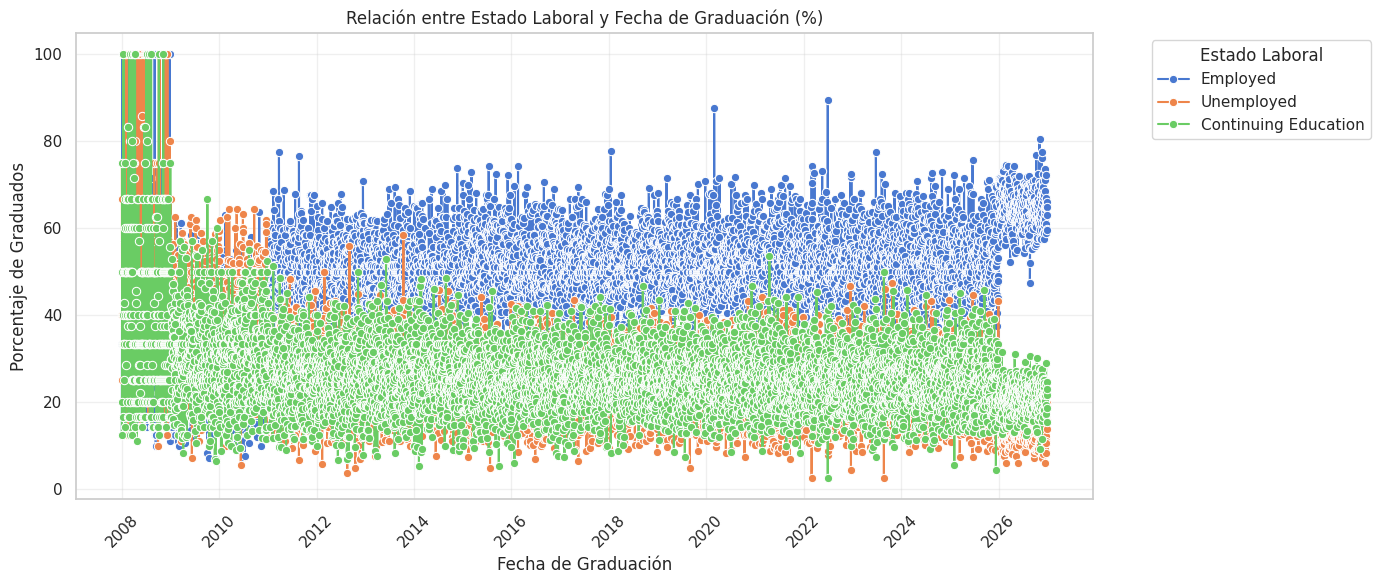


--- Análisis de Graduados Recientes (2026-12-31) ---
Cantidad de graduados recientes trabajando: 82
Tasa de empleo para los más recientes: 63.08%


In [29]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Re-asegurar Sesión de Spark
spark = SparkSession.builder.appName('CuboOLAPColab').master('local[*]').getOrCreate()

# 2. Re-cargar datos necesarios
base_path = '/content/CUBO-OLAP'
dim_time = spark.read.option('header', 'true').option('inferSchema', 'true').csv(f'{base_path}/dim_time.csv')
fact_employability = spark.read.option('header', 'true').option('inferSchema', 'true').csv(f'{base_path}/fact_employability.csv')

# 3. Reconstruir el cubo (mínimo necesario para esta consulta)
cube_df = fact_employability.join(dim_time, 'time_id', 'left')

# 4. Procesamiento para la pregunta
graduation_employment = cube_df.groupBy('graduation_date', 'employment_status') \
    .agg(F.count('*').alias('cantidad')) \
    .orderBy('graduation_date')

# Convertimos a Pandas para graficar
pdf_grad = graduation_employment.toPandas()

# Calculamos el porcentaje por fecha para comparar proporciones reales
total_per_date = pdf_grad.groupby('graduation_date')['cantidad'].transform('sum')
pdf_grad['porcentaje'] = (pdf_grad['cantidad'] / total_per_date) * 100

# 5. Visualización: Job Status vs Fecha de Graduación
plt.figure(figsize=(14, 6))
sns.lineplot(data=pdf_grad, x='graduation_date', y='porcentaje', hue='employment_status', marker='o')
plt.title('Relación entre Estado Laboral y Fecha de Graduación (%)')
plt.ylabel('Porcentaje de Graduados')
plt.xlabel('Fecha de Graduación')
plt.legend(title='Estado Laboral', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Respuesta específica sobre graduados recientes
recent_date = pdf_grad['graduation_date'].max()
recent_data = pdf_grad[pdf_grad['graduation_date'] == recent_date]
employed_recent = recent_data[recent_data['employment_status'] == 'Employed']

print(f'\n--- Análisis de Graduados Recientes ({recent_date}) ---')
if not employed_recent.empty:
    print(f"Cantidad de graduados recientes trabajando: {employed_recent['cantidad'].values[0]}")
    print(f"Tasa de empleo para los más recientes: {employed_recent['porcentaje'].values[0]:.2f}%")

In [30]:
# Análisis de graduados recientes vs antiguos
if 'pdf_grad' in locals():
    recent_date = pdf_grad['graduation_date'].max()
    oldest_date = pdf_grad['graduation_date'].min()

    print(f"Rango de graduación: desde {oldest_date} hasta {recent_date}")

    # Calculamos totales para recientes (última fecha disponible)
    recent_stats = pdf_grad[pdf_grad['graduation_date'] == recent_date]
    print(f"\nEstadísticas para la fecha más reciente ({recent_date}):")
    print(recent_stats[['employment_status', 'cantidad', 'porcentaje']])

Rango de graduación: desde 2008-01-01 hasta 2026-12-31

Estadísticas para la fecha más reciente (2026-12-31):
          employment_status  cantidad  porcentaje
20583              Employed        82   63.076923
20584            Unemployed        18   13.846154
20585  Continuing Education        30   23.076923


### 9. Evolución Mensual de la Tasa de Inserción por Nivel Educativo
Analizamos cómo varía la probabilidad de empleo mes a mes para el último año registrado.

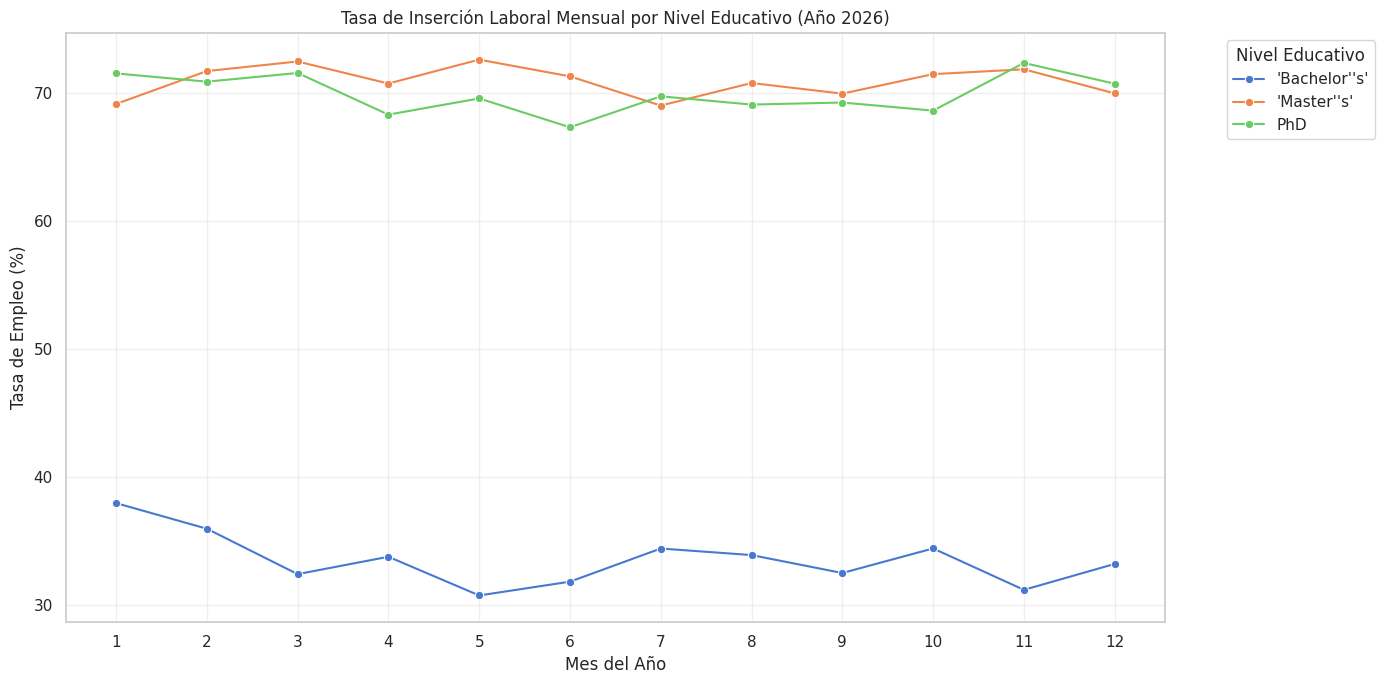


--- Resultado del último año (2026) ---
El perfil formativo que maximiza la probabilidad de empleo es: 'Master''s' con una tasa promedio del 70.95%

Ranking de empleabilidad promedio por nivel:
education_level
'Master''s'      70.947536
PhD              69.944605
'Bachelor''s'    33.521606
Name: employment_rate, dtype: float64


In [32]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reconstruir el cubo completo para asegurar que 'education_level' existe
cube_df = fact_employability \
    .join(dim_candidate, 'candidate_id', 'left') \
    .join(dim_education, 'education_id', 'left') \
    .join(dim_skills, 'skills_id', 'left') \
    .join(dim_time, 'time_id', 'left')

# 2. Extraer año y mes
cube_monthly = cube_df.withColumn('year', F.year('graduation_date')) \
                      .withColumn('month', F.month('graduation_date'))

# 3. Buscar el último año disponible
last_year = cube_monthly.select(F.max('year')).collect()[0][0]

# 4. Calcular estadísticas mensuales por nivel educativo
monthly_stats = cube_monthly.filter(F.col('year') == last_year) \
    .groupBy('month', 'education_level') \
    .agg(
        F.count('*').alias('total'),
        F.sum(F.when(F.col('employment_status') == 'Employed', 1).otherwise(0)).alias('employed')
    ) \
    .withColumn('employment_rate', (F.col('employed') / F.col('total')) * 100) \
    .orderBy('month', 'education_level')

# 5. Visualización
pdf_monthly = monthly_stats.toPandas()
plt.figure(figsize=(14, 7))
sns.lineplot(data=pdf_monthly, x='month', y='employment_rate', hue='education_level', marker='o')
plt.title(f'Tasa de Inserción Laboral Mensual por Nivel Educativo (Año {last_year})')
plt.xlabel('Mes del Año')
plt.ylabel('Tasa de Empleo (%)')
plt.xticks(range(1, 13))
plt.legend(title='Nivel Educativo', bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Identificar el perfil que maximiza la probabilidad en el último año
ranking = pdf_monthly.groupby('education_level')['employment_rate'].mean().sort_values(ascending=False)
best_profile = ranking.index[0]
max_rate = ranking.iloc[0]

print(f'\n--- Resultado del último año ({last_year}) ---')
print(f'El perfil formativo que maximiza la probabilidad de empleo es: {best_profile} con una tasa promedio del {max_rate:.2f}%')
print('\nRanking de empleabilidad promedio por nivel:')
print(ranking)